In [2]:
import pandas as pd

# Загружаем датасет (убедитесь, что файл wan_telemetry.csv лежит в папке C:\Users\Husky\Desktop\AVR)
df_raw = pd.read_csv('wan_dataset.csv') 

print("--- Названия колонок в датасете ---")
print(df_raw.columns.tolist())
print("\n--- Первые 3 строки ---")
print(df_raw.head(3))

--- Названия колонок в датасете ---
['timestamp', 'link_id', 'source_device', 'destination_device', 'source_interface', 'destination_interface', 'link_utilization', 'latency_ms', 'packet_loss', 'throughput_mbps', 'qos_priority', 'reachability', 'traffic_type', 'anomaly_flag']

--- Первые 3 строки ---
   timestamp link_id source_device destination_device source_interface  \
0          0  link_1        host_1           switch_1      interface_1   
1          0  link_2        host_2           switch_3      interface_2   
2          0  link_3        host_3           switch_1      interface_3   

  destination_interface  link_utilization  latency_ms  packet_loss  \
0           interface_1                50          35          0.0   
1           interface_4                83          28          1.2   
2           interface_7                86          13          0.4   

   throughput_mbps  qos_priority  reachability traffic_type  anomaly_flag  
0              200             1            

Приведение к формату Nixtla

Всего линков в срезе сети: 2000
Обнаружено аномальных каналов: 40


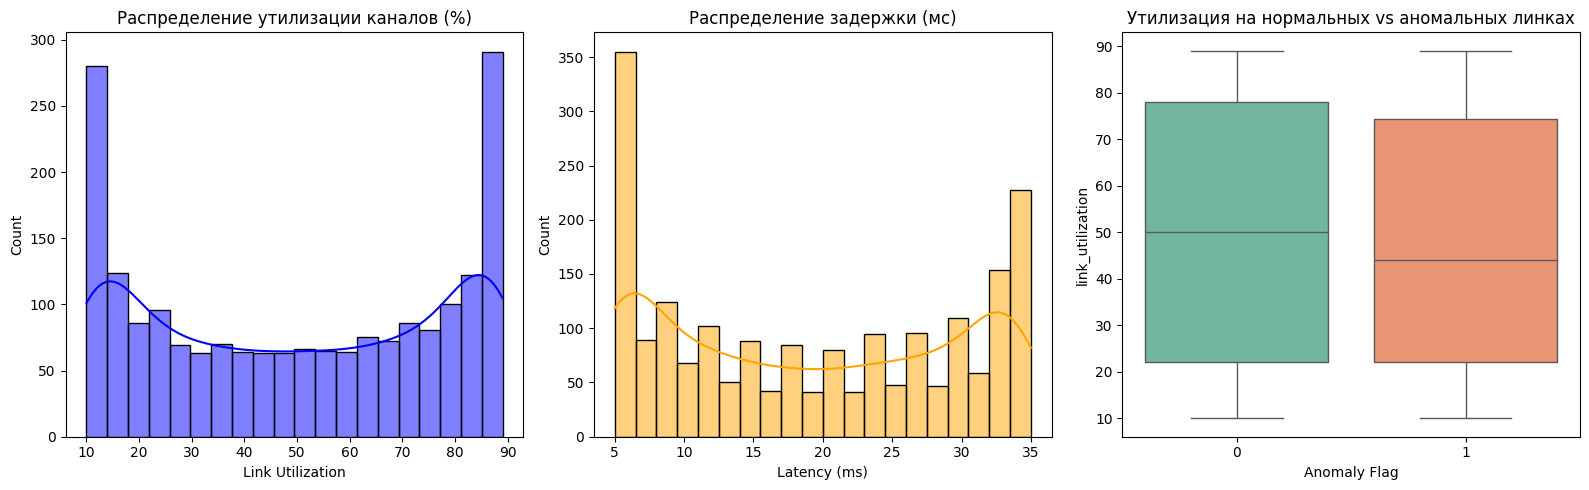

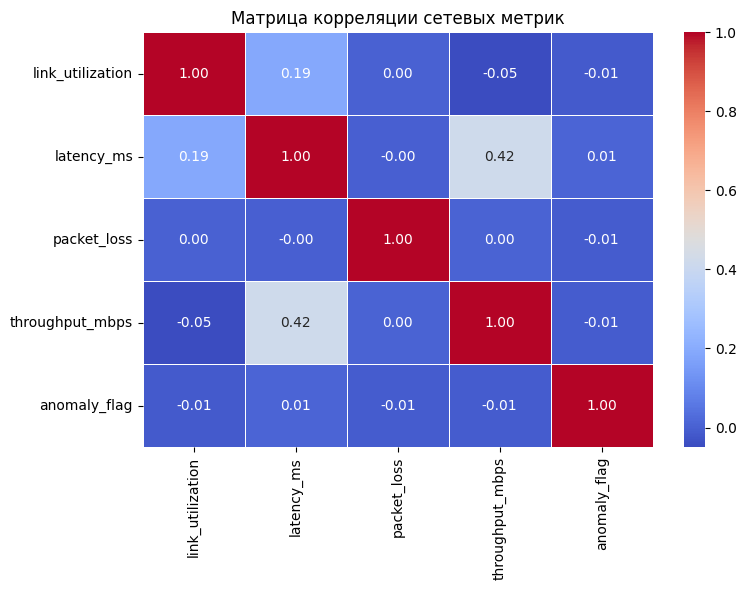

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем ваш реальный файл
df_analysis = pd.read_csv('wan_dataset.csv')

# Приводим типы к числовым (на всякий случай, чтобы избежать ошибок)
df_analysis['link_utilization'] = pd.to_numeric(df_analysis['link_utilization'], errors='coerce')
df_analysis['latency_ms'] = pd.to_numeric(df_analysis['latency_ms'], errors='coerce')
df_analysis['packet_loss'] = pd.to_numeric(df_analysis['packet_loss'], errors='coerce')
df_analysis['throughput_mbps'] = pd.to_numeric(df_analysis['throughput_mbps'], errors='coerce')

print(f"Всего линков в срезе сети: {len(df_analysis)}")
print(f"Обнаружено аномальных каналов: {df_analysis['anomaly_flag'].sum()}")

# 2. Строим графики распределения метрик
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_analysis['link_utilization'], kde=True, color='blue', bins=20)
plt.title('Распределение утилизации каналов (%)')
plt.xlabel('Link Utilization')

plt.subplot(1, 3, 2)
sns.histplot(df_analysis['latency_ms'], kde=True, color='orange', bins=20)
plt.title('Распределение задержки (мс)')
plt.xlabel('Latency (ms)')

plt.subplot(1, 3, 3)
sns.boxplot(x='anomaly_flag', y='link_utilization', data=df_analysis, hue='anomaly_flag', palette='Set2', legend=False)
plt.title('Утилизация на нормальных vs аномальных линках')
plt.xlabel('Anomaly Flag')

plt.tight_layout()
plt.show()

# 3. Матрица корреляции между метриками сети
plt.figure(figsize=(8, 6))
numeric_cols = ['link_utilization', 'latency_ms', 'packet_loss', 'throughput_mbps', 'anomaly_flag']
corr_matrix = df_analysis[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции сетевых метрик')
plt.tight_layout()
plt.show()

Анализ тренда, сезонности и автокорреляции (EDA)

Количество строк по каналам:
unique_id
link_1    200
link_2    200
link_3    200
link_4    200
link_5    200
Name: count, dtype: int64

Анализируем канал с maximal количеством данных: link_1
Всего точек для анализа: 200, выбранный период сезонности: 24


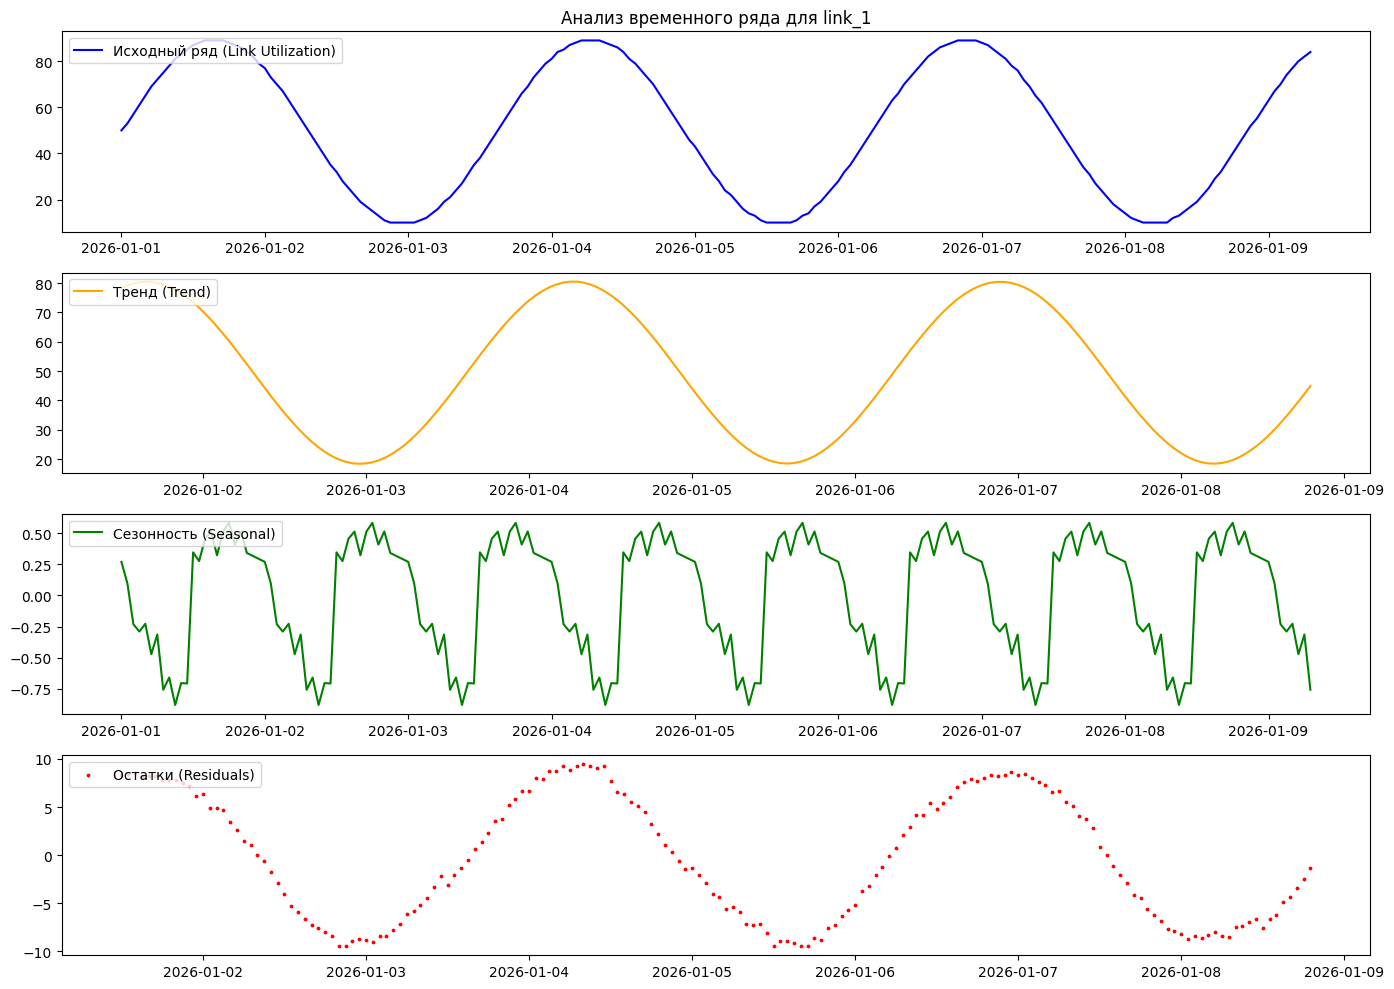

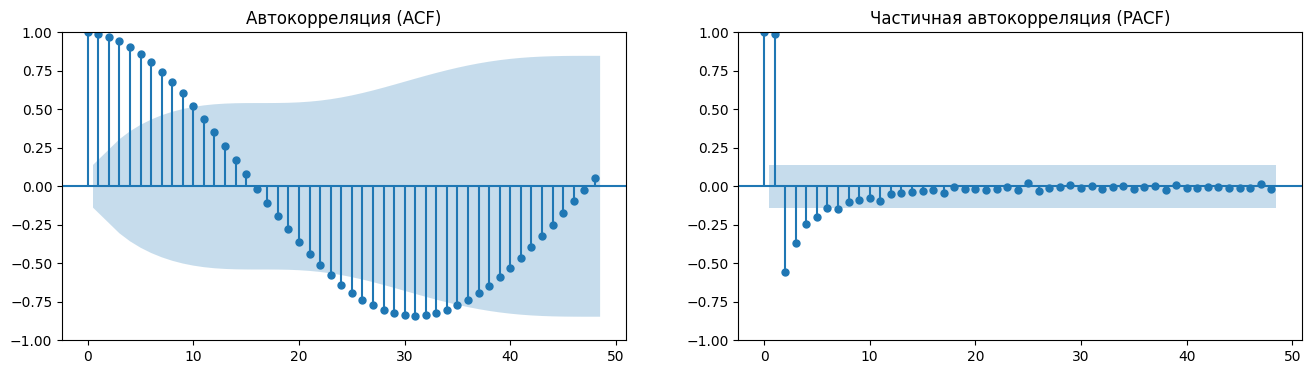

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Загрузка данных
df = pd.read_csv('wan_dataset.csv')

# Хитрый фикс перевода целочисленных часов в честный datetime
df['datetime'] = pd.to_datetime('2026-01-01') + pd.to_timedelta(df['timestamp'], unit='h')

df_nixtla = df[['link_id', 'datetime', 'link_utilization']].rename(
    columns={
        'link_id': 'unique_id',
        'datetime': 'ds',
        'link_utilization': 'y'
    }
)

# 1. Посмотрим, сколько точек в каждом канале, чтобы не наткнуться на пустышку
counts = df_nixtla['unique_id'].value_counts()
print("Количество строк по каналам:")
print(counts.head(5))

# Автоматически берем тот канал, где больше всего наблюдений
target_link = counts.index[0]
print(f"\nАнализируем канал с maximal количеством данных: {target_link}")

# Фильтруем данные и жестко дропаем дубли, если они проскочили
df_link = df_nixtla[df_nixtla['unique_id'] == target_link].copy()
df_link = df_link.drop_duplicates(subset=['ds']).set_index('ds')

# Выставляем частоту ряда. Заполняем пропуски линейной интерполяцией
df_link = df_link.asfreq(df_link.index.inferred_freq or 'H')
df_link['y'] = df_link['y'].interpolate(method='linear')

# Вычисляем адекватный период для декомпозиции
total_observations = len(df_link)
chosen_period = 24 if total_observations >= 48 else max(2, total_observations // 2 - 1)

print(f"Всего точек для анализа: {total_observations}, выбранный период сезонности: {chosen_period}")

# 2. Сама декомпозиция
if total_observations >= chosen_period * 2:
    decomposition = seasonal_decompose(df_link['y'], model='additive', period=chosen_period)

    plt.figure(figsize=(14, 10))
    plt.subplot(4, 1, 1)
    plt.plot(df_link['y'], label='Исходный ряд (Link Utilization)', color='blue')
    plt.title(f'Анализ временного ряда для {target_link}')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 2)
    plt.plot(decomposition.trend, label='Тренд (Trend)', color='orange')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 3)
    plt.plot(decomposition.seasonal, label='Сезонность (Seasonal)', color='green')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 4)
    plt.scatter(df_link.index, decomposition.resid, label='Остатки (Residuals)', color='red', s=3)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. ACF и PACF (лаги берем пропорционально размеру данных)
    max_lags = min(48, total_observations // 2 - 1)
    if max_lags > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
        plot_acf(df_link['y'].dropna(), lags=max_lags, ax=ax1, title='Автокорреляция (ACF)')
        # Метод yule_walker заменен на дефолтный стабильный для дельты дат
        plot_pacf(df_link['y'].dropna(), lags=max_lags, ax=ax2, title='Частичная автокорреляция (PACF)')
        plt.show()
    else:
        print("Данных слишком мало для построения графиков ACF/PACF")
else:
    print(f"Критически мало данных ({total_observations} шт.) для декомпозиции с периодом {chosen_period}. Требуется минимум {chosen_period * 2}.")

Задача №2

Размер обучающей выборки: 1600 строк
Размер тестовой выборки: 400 строк

================ МЕТРИКИ: RANDOM FOREST ================
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       392
           1       0.67      0.25      0.36         8

    accuracy                           0.98       400
   macro avg       0.83      0.62      0.68       400
weighted avg       0.98      0.98      0.98       400

ROC-AUC Score: 0.9955

================ МЕТРИКИ: CATBOOST ================
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       392
           1       0.75      0.38      0.50         8

    accuracy                           0.98       400
   macro avg       0.87      0.69      0.75       400
weighted avg       0.98      0.98      0.98       400

ROC-AUC Score: 0.9971


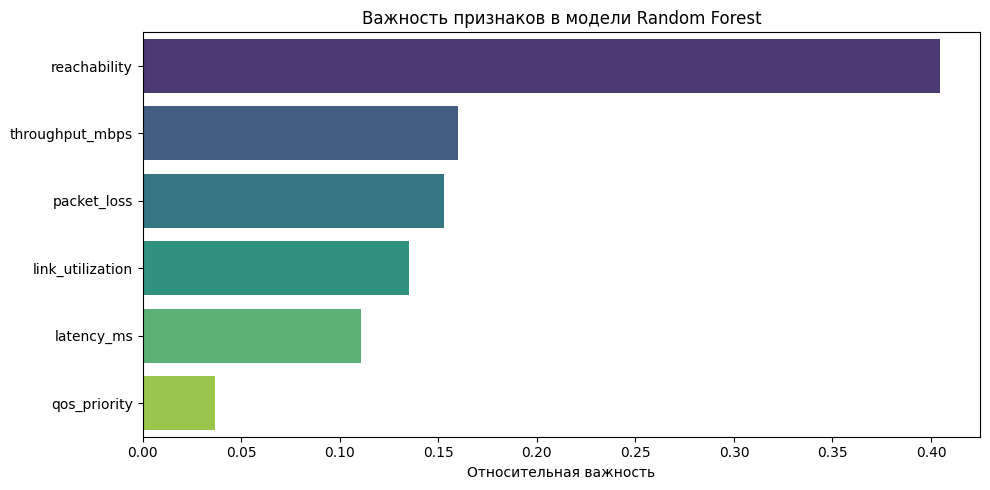

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Использовать для градиентного бустинга, если библиотека установлена
# Если CatBoost не ставили, пока закомментируйте эти строки
try:
    from catboost import CatBoostClassifier
    has_catboost = True
except ImportError:
    has_catboost = False

# 1. Загрузка и подготовка данных
df_model = pd.read_csv('wan_dataset.csv')

# Выбираем числовые признаки для обучения и таргет
feature_cols = ['link_utilization', 'latency_ms', 'packet_loss', 'throughput_mbps', 'qos_priority', 'reachability']
X = df_model[feature_cols].copy()
y = df_model['anomaly_flag']

# Заполняем возможные пропуски медианой
X = X.fillna(X.median())

# 2. Разделение на обучающую и тестовую выборки (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

# --- Модель 1: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n================ МЕТРИКИ: RANDOM FOREST ================")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# --- Модель 2: CatBoost (если доступен) ---
if has_catboost:
    cb_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
    cb_model.fit(X_train, y_train)
    y_pred_cb = cb_model.predict(X_test)
    y_prob_cb = cb_model.predict_proba(X_test)[:, 1]
    
    print("\n================ МЕТРИКИ: CATBOOST ================")
    print(classification_report(y_test, y_pred_cb))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_cb):.4f}")

# 3. Визуализация важности признаков (Feature Importance) для Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features_y = [feature_cols[i] for i in indices]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=features_y, hue=features_y, palette='viridis', legend=False)
plt.title('Важность признаков в модели Random Forest')
plt.xlabel('Относительная важность')
plt.tight_layout()
plt.show()

Задача №3

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

print("--- Старт оптимизации гиперпараметров для Random Forest ---")

# 1. Задаем сетку параметров для перебора
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

# 2. Настраиваем поиск по сетке с кросс-валидацией (5 фолдов)
# Оптимизируем f1-score (баланс Precision и Recall)
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучаем сетку
grid_search_rf.fit(X_train, y_train)

# 3. Выводим лучшие параметры
best_rf = grid_search_rf.best_estimator_
print(f"\nЛучшие параметры RF: {grid_search_rf.best_params_}")

# Проверяем качество оптимизированной модели на тестовой выборке
y_pred_best_rf = best_rf.predict(X_test)
print("\n================ МЕТРИКИ: OPTIMIZED RANDOM FOREST ================")
print(classification_report(y_test, y_pred_best_rf))


# --- Оптимизация CatBoost (опционально, если модуль доступен) ---
if has_catboost:
    print("\n--- Старт быстрой оптимизации для CatBoost ---")
    cb_tune = CatBoostClassifier(iterations=300, random_seed=42, verbose=0)
    
    # Используем встроенный в CatBoost быстрый grid_search
    grid_cb = {'depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1]}
    cb_tune.grid_search(grid_cb, X_train, y_train, cv=3, partition_random_seed=42, verbose=False)
    
    y_pred_cb_tune = cb_tune.predict(X_test)
    print("\n================ МЕТРИКИ: OPTIMIZED CATBOOST ================")
    print(classification_report(y_test, y_pred_cb_tune))

--- Старт оптимизации гиперпараметров для Random Forest ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Лучшие параметры RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

================ МЕТРИКИ: OPTIMIZED RANDOM FOREST ================
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       392
           1       0.67      0.25      0.36         8

    accuracy                           0.98       400
   macro avg       0.83      0.62      0.68       400
weighted avg       0.98      0.98      0.98       400


--- Старт быстрой оптимизации для CatBoost ---

bestTest = 0.04343638174
bestIteration = 77


bestTest = 0.04285080171
bestIteration = 44


bestTest = 0.04452105595
bestIteration = 21


bestTest = 0.0455911508
bestIteration = 115


bestTest = 0.04679462491
bestIteration = 43


bestTest = 0.04586494228
bestIteration = 29


bestTest = 0.04481269352
bestIteration = 89


bestTest = 0.04949172046
best

Задача 4
Отчет в README

In [27]:
# Сохраняем лучшую модель CatBoost в файл
cb_tune.save_model('best_catboost_model.cbm')

print("--- Задача №4 выполнена успешно! ---")
print("Модель сериализована и сохранена как 'best_catboost_model.cbm'")

--- Задача №4 выполнена успешно! ---
Модель сериализована и сохранена как 'best_catboost_model.cbm'
